In [11]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/clean', exist_ok=True)

n = 15000

dates = pd.date_range(start='2024-04-01', end='2024-06-30', periods=n)

df = pd.DataFrame({
    'tx_id': [f"TX_{100000 + i}" for i in range(n)],
    'card_id': [f"CARD_{np.random.randint(1000, 2000)}" for _ in range(n)],
    'customer_id': [f"CUST_{np.random.randint(500, 1000)}" for _ in range(n)],
    'auth_ts': dates.strftime('%Y-%m-%d %H:%M:%S'),
    'post_ts': (dates + pd.Timedelta(hours=2)).strftime('%Y-%m-%d %H:%M:%S'),
    'tz': np.random.choice(['UTC', 'Kyiv', 'Europe/Kyiv'], size=n),
    'amount_tx_currency': np.round(np.random.uniform(5.0, 500.0, size=n), 2),
    'tx_currency': np.random.choice(['UAH', 'USD', 'EUR'], size=n, p=[0.7, 0.2, 0.1]),
    'fx_rate': 1.0,
    'mcc': np.random.choice([5411, 5812, 5912, 5311, 4111], size=n),
    'merchant_name': np.random.choice(['Silpo', 'Rozetka', 'Uber', 'A pharmacy', 'McDonalds'], size=n),
    'country_iso2': np.random.choice(['UA', 'US', 'DE', 'PL'], size=n, p=[0.8, 0.1, 0.05, 0.05]),
    'channel': np.random.choice(['pos', 'ecom', 'atm'], size=n, p=[0.6, 0.3, 0.1]),
    'status': np.random.choice(['auth_only', 'posted', 'reversed', 'chargeback'], size=n, p=[0.1, 0.8, 0.07, 0.03]),
    'fee_uah': np.round(np.random.uniform(0, 15.0, size=n), 2),
    'note': 'regular tx'
})

df.loc[df['tx_currency'] == 'USD', 'fx_rate'] = 39.5
df.loc[df['tx_currency'] == 'EUR', 'fx_rate'] = 42.8
df['amount_uah'] = np.round(df['amount_tx_currency'] * df['fx_rate'], 2)

df.loc[np.random.choice(n, int(n * 0.10), replace=False), 'amount_uah'] = np.nan
df.loc[np.random.choice(n, int(n * 0.08), replace=False), 'fx_rate'] = np.nan
df.loc[np.random.choice(n, int(n * 0.06), replace=False), 'mcc'] = np.nan
df.loc[np.random.choice(n, int(n * 0.05), replace=False), 'merchant_name'] = np.nan

full_dups = df.iloc[:int(n * 0.02)].copy()
df = pd.concat([df, full_dups], ignore_index=True)

dt_idx = np.random.choice(len(df), int(len(df) * 0.12), replace=False)
df.loc[dt_idx, 'auth_ts'] = pd.to_datetime(df.loc[dt_idx, 'auth_ts']).dt.strftime('%d.%m.%Y %H:%M:%S')

df['country_iso2'] = df['country_iso2'].astype(object)
c_idx = np.random.choice(len(df), int(len(df) * 0.10), replace=False)
df.loc[c_idx, 'country_iso2'] = df.loc[c_idx, 'country_iso2'].apply(lambda x: f" {str(x).lower()} ")

df['amount_tx_currency'] = df['amount_tx_currency'].astype(object)
num_idx = np.random.choice(len(df), int(len(df) * 0.08), replace=False)
df.loc[num_idx, 'amount_tx_currency'] = df.loc[num_idx, 'amount_tx_currency'].apply(lambda x: f"{x:,.2f} UAH")

df.loc[np.random.choice(len(df), int(len(df) * 0.01), replace=False), 'mcc'] = 99999
df.loc[df['status'] == 'posted', 'post_ts'] = df.loc[df['status'] == 'posted', 'post_ts'].where(np.random.rand(sum(df['status'] == 'posted')) > 0.008, np.nan)

df.to_csv('../data/raw/card_transactions_flat.csv', index=False)
print("Done! Raw fintech dataset generated.")

Done! Raw fintech dataset generated.


In [12]:
import pandas as pd

df_raw = pd.read_csv('../data/raw/card_transactions_flat.csv')

print(df_raw.shape)
print(df_raw.dtypes)
print((df_raw.isnull().mean() * 100).round(2))
print(f"Duplicates: {df_raw.duplicated().sum()}")
print(df_raw['status'].value_counts(dropna=False))
print(df_raw.describe())

(15300, 17)
tx_id                     str
card_id                   str
customer_id               str
auth_ts                   str
post_ts                   str
tz                        str
amount_tx_currency        str
tx_currency               str
fx_rate               float64
mcc                   float64
merchant_name             str
country_iso2              str
channel                   str
status                    str
fee_uah               float64
note                      str
amount_uah            float64
dtype: object
tx_id                  0.00
card_id                0.00
customer_id            0.00
auth_ts                0.00
post_ts                0.71
tz                     0.00
amount_tx_currency     0.00
tx_currency            0.00
fx_rate                8.01
mcc                    5.95
merchant_name          4.97
country_iso2           0.00
channel                0.00
status                 0.00
fee_uah                0.00
note                   0.00
amount_uah      

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/card_transactions_flat.csv')
change_log = []

def log_change(field, rule, count, example):
    change_log.append({'Field': field, 'Rule': rule, 'Records_Affected': count, 'Example': example})

init_len = len(df)
df = df.drop_duplicates()
log_change('All', 'Remove full duplicates', init_len - len(df), 'Dropped duplicates')

df['amount_tx_currency'] = df['amount_tx_currency'].astype(str).str.replace('UAH', '', regex=False).str.replace(',', '', regex=False)
df['amount_tx_currency'] = pd.to_numeric(df['amount_tx_currency'], errors='coerce')

df['fx_rate'] = df['fx_rate'].fillna(df['tx_currency'].map({'UAH': 1.0, 'USD': 39.5, 'EUR': 42.8}))
df['fx_filled'] = df['fx_rate'].isnull().astype(int)

df['amount_uah'] = df['amount_uah'].fillna(df['amount_tx_currency'] * df['fx_rate'])

df.loc[df['status'].isin(['reversed', 'chargeback']) & (df['amount_uah'] > 0), 'amount_uah'] *= -1

df['country_iso2'] = df['country_iso2'].astype(str).str.strip().str.upper()

df['mcc'] = pd.to_numeric(df['mcc'], errors='coerce')
df.loc[(df['mcc'] < 1) | (df['mcc'] > 9999), 'mcc'] = np.nan

df['missing_posted_ts'] = ((df['status'] == 'posted') & (df['post_ts'].isnull())).astype(int)

df['auth_ts'] = pd.to_datetime(df['auth_ts'], format='mixed', errors='coerce')
df['tz'] = 'Kyiv'

df = df.drop_duplicates()

df.to_csv('../data/clean/dataset_clean.csv', index=False)
pd.DataFrame(change_log).to_csv('../change_log.csv', index=False)

assert df['amount_tx_currency'].dtype == 'float64'
assert df.duplicated().sum() == 0
assert df['amount_uah'].isnull().sum() == 0
assert (df['tz'] == 'Kyiv').all()
assert (df.loc[df['status'] == 'chargeback', 'amount_uah'] <= 0).all()
assert df['mcc'].dropna().between(1, 9999).all()
assert 'missing_posted_ts' in df.columns
assert len(df) > 10000

print("Cleaned successfully!")

Cleaned successfully!


Raw: 15300 | Clean: 15068
tx_id                    0
card_id                  0
customer_id              0
auth_ts                  0
post_ts                108
tz                       0
amount_tx_currency       0
tx_currency              0
fx_rate                  0
mcc                   1046
merchant_name          751
country_iso2             0
channel                  0
status                   0
fee_uah                  0
note                     0
amount_uah               0
fx_filled                0
missing_posted_ts        0
dtype: int64


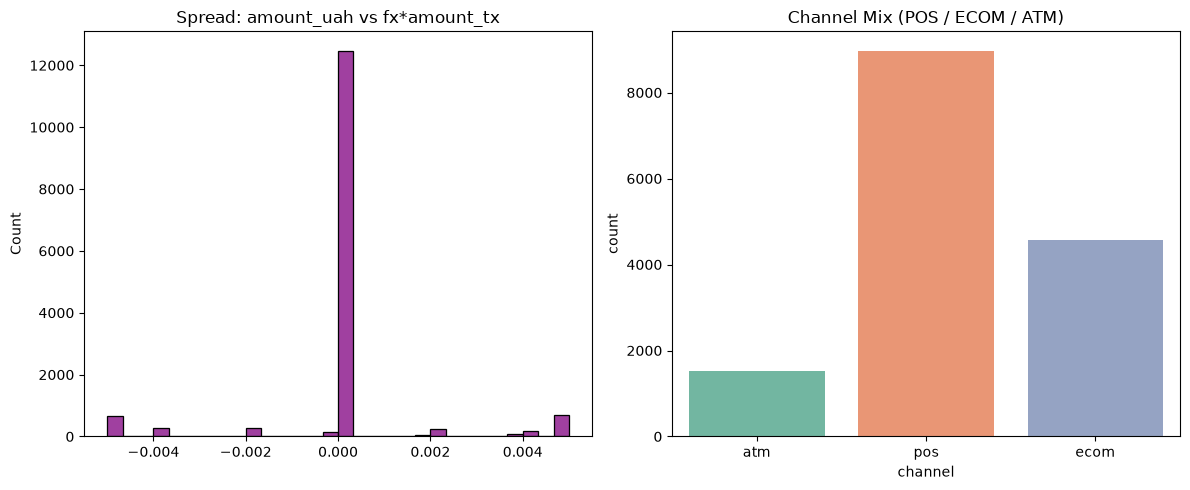

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/raw/card_transactions_flat.csv')
df_clean = pd.read_csv('../data/clean/dataset_clean.csv')

print(f"Raw: {df_raw.shape[0]} | Clean: {df_clean.shape[0]}")
print(df_clean.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spread = df_clean['amount_uah'].abs() - (df_clean['amount_tx_currency'] * df_clean['fx_rate'])
sns.histplot(spread, ax=axes[0], color='purple', bins=30)
axes[0].set_title('Spread: amount_uah vs fx*amount_tx')

sns.countplot(data=df_clean, x='channel', hue='channel', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Channel Mix (POS / ECOM / ATM)')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

df = pd.read_csv('../data/clean/dataset_clean.csv')

kpi_1 = df[df['status'] == 'posted']['amount_uah'].sum()
kpi_2 = (df['tx_currency'] != 'UAH').mean() * 100
kpi_3 = (df['status'] == 'chargeback').mean() * 100
kpi_4 = (df[df['status'] == 'posted']['missing_posted_ts'] == 0).mean() * 100
kpi_5 = df['fee_uah'].sum() / df['amount_uah'].abs().sum() * 100
kpi_6 = df['mcc'].mode()[0]
kpi_7 = df['country_iso2'].value_counts(normalize=True).to_dict()
kpi_8 = df['fx_filled'].mean() * 100
kpi_9 = len(df)
kpi_10 = df['channel'].value_counts(normalize=True).max() * 100

print(f"1. Total Volume (UAH) [posted]: ${kpi_1:,.2f}")
print(f"2. FX Share: {kpi_2:.2f}%")
print(f"3. Chargeback Rate: {kpi_3:.2f}%")
print(f"4. Pairing Proxy (Valid post_ts): {kpi_4:.2f}%")
print(f"5. Fee Yield: {kpi_5:.4f}%")
print(f"6. Top MCC Code: {kpi_6:.0f}")
print(f"7. Geo Mix (ISO-2): {kpi_7}")
print(f"8. FX Filled Share: {kpi_8:.2f}%")
print(f"9. Clean Total Records: {kpi_9}")
print(f"10. Top Channel Share: {kpi_10:.2f}%")

1. Total Volume (UAH) [posted]: $39,672,756.30
2. FX Share: 30.61%
3. Chargeback Rate: 2.93%
4. Pairing Proxy (Valid post_ts): 99.10%
5. Fee Yield: 0.2248%
6. Top MCC Code: 5812
7. Geo Mix (ISO-2): {'UA': 0.8051499867268384, 'US': 0.09875232280329174, 'PL': 0.05130076984337669, 'DE': 0.04479692062649323}
8. FX Filled Share: 0.00%
9. Clean Total Records: 15068
10. Top Channel Share: 59.56%
